# 01 — BPO SLA Performance: Modeling (enfoque científico)

Continúa desde [`02_data_preparation.ipynb`](./02_data_preparation.ipynb). El enfoque **analista** (volumen por producto/idioma, tasa de cumplimiento por agente, teoría de colas) ya se cubrió de forma descriptiva en la sección 11 del EDA. Este notebook es el enfoque **científico**: entrenar y comparar modelos de clasificación que predigan el riesgo de incumplimiento de SLA usando únicamente información disponible *antes* de conocer el resultado del día (sin `avg_aht`, ver el hallazgo de leakage en el EDA).

**Alcance de este notebook:** entrenar un baseline y un modelo principal, y compararlos con métricas estándar de clasificación. La optimización del umbral de decisión en función del costo de negocio (sub-dotación vs sobre-dotación) se deja para `04_evaluation.ipynb`, que es un paso distinto del framework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Carga de datos procesados

In [2]:
train = pd.read_csv('../data/processed_train.csv', parse_dates=['date'])
test = pd.read_csv('../data/processed_test.csv', parse_dates=['date'])

assert list(train.columns) == list(test.columns), 'Train y test deben tener el mismo esquema'
print('Train:', train.shape, '| Test:', test.shape)

Train: (171, 25) | Test: (99, 25)


## 2. Reencuadre del target: `sla_risk`

El dataset trae `std_pass` (1 = cumple). La pregunta de negocio es "¿qué tickets están en riesgo de **incumplir**?", así que se define `sla_risk = 1 - std_pass` como variable objetivo: la clase positiva (1) pasa a ser "en riesgo de incumplir SLA". Esto alinea directamente el recall de la clase positiva con lo que le importa al negocio (cuántos incumplimientos reales se detectan).

In [3]:
drop_cols = ['date', 'std_pass']

X_train = train.drop(columns=drop_cols)
y_train = 1 - train['std_pass']
X_test = test.drop(columns=drop_cols)
y_test = 1 - test['std_pass']

numeric_cols = ['calls_handled', 'agent_prior_pass_rate', 'agent_prior_avg_calls']
passthrough_cols = [c for c in X_train.columns if c not in numeric_cols]

print('Features numéricas a escalar:', numeric_cols)
print('Features binarias (passthrough):', len(passthrough_cols))
print()
print('Tasa de sla_risk — train:', y_train.mean().round(3), '| test:', y_test.mean().round(3))

Features numéricas a escalar: ['calls_handled', 'agent_prior_pass_rate', 'agent_prior_avg_calls']
Features binarias (passthrough): 20

Tasa de sla_risk — train: 0.415 | test: 0.354


## 3. Baseline trivial

Antes de evaluar modelos reales, se fija el piso: un clasificador que siempre predice la clase mayoritaria del train ("nunca en riesgo"). Cualquier modelo real debe superarlo claramente, si no, no aporta valor.

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(classification_report(y_test, dummy_pred, target_names=['cumple', 'en riesgo'], zero_division=0))

              precision    recall  f1-score   support

      cumple       0.65      1.00      0.79        64
   en riesgo       0.00      0.00      0.00        35

    accuracy                           0.65        99
   macro avg       0.32      0.50      0.39        99
weighted avg       0.42      0.65      0.51        99



Como se esperaba: 0% de recall en la clase de interés ("en riesgo") — el baseline nunca detecta un incumplimiento. Este es el piso a superar.

## 4. Modelo baseline: Regresión Logística

Se escala solo `calls_handled`, `agent_prior_pass_rate` y `agent_prior_avg_calls` (el resto ya son 0/1). El escalado se ajusta únicamente sobre train, dentro del `Pipeline`, para no filtrar estadísticas del test set. `class_weight='balanced'` porque al negocio le interesa más el recall de "en riesgo" que la accuracy global.

In [5]:
preprocess = ColumnTransformer([
    ('scale', StandardScaler(), numeric_cols),
], remainder='passthrough')

logreg = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, logreg_pred, target_names=['cumple', 'en riesgo'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, logreg_proba), 3))
print('PR-AUC (average precision):', round(average_precision_score(y_test, logreg_proba), 3))

              precision    recall  f1-score   support

      cumple       0.98      0.89      0.93        64
   en riesgo       0.83      0.97      0.89        35

    accuracy                           0.92        99
   macro avg       0.91      0.93      0.91        99
weighted avg       0.93      0.92      0.92        99

ROC-AUC: 0.971
PR-AUC (average precision): 0.931


## 5. Modelo principal: XGBoost

Hiperparámetros conservadores (`max_depth=3`, pocos estimadores, subsampling) porque el dataset es pequeño (171 filas de train) y un árbol profundo memoriza en vez de generalizar.

In [6]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred, target_names=['cumple', 'en riesgo'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, xgb_proba), 3))
print('PR-AUC (average precision):', round(average_precision_score(y_test, xgb_proba), 3))

              precision    recall  f1-score   support

      cumple       0.98      0.94      0.96        64
   en riesgo       0.89      0.97      0.93        35

    accuracy                           0.95        99
   macro avg       0.94      0.95      0.95        99
weighted avg       0.95      0.95      0.95        99


ROC-AUC: 0.994
PR-AUC (average precision): 0.99


## 6. Comparación de modelos

In [7]:
def summarize(name, y_true, y_pred, y_proba):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        'modelo': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision (en riesgo)': precision_score(y_true, y_pred, zero_division=0),
        'recall (en riesgo)': recall_score(y_true, y_pred, zero_division=0),
        'f1 (en riesgo)': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
    }

results = pd.DataFrame([
    summarize('Dummy (mayoría)', y_test, dummy_pred, dummy.predict_proba(X_test)[:, 1]),
    summarize('Logistic Regression', y_test, logreg_pred, logreg_proba),
    summarize('XGBoost', y_test, xgb_pred, xgb_proba),
]).set_index('modelo').round(3)

results

,accuracy,precision (en riesgo),recall (en riesgo),f1 (en riesgo),roc_auc,pr_auc
modelo,,,,,,
Dummy (mayoría),0.646,0.000,0.000,0.000,0.500,0.354
Logistic Regression,0.919,0.829,0.971,0.895,0.971,0.931
XGBoost,0.949,0.895,0.971,0.932,0.994,0.990


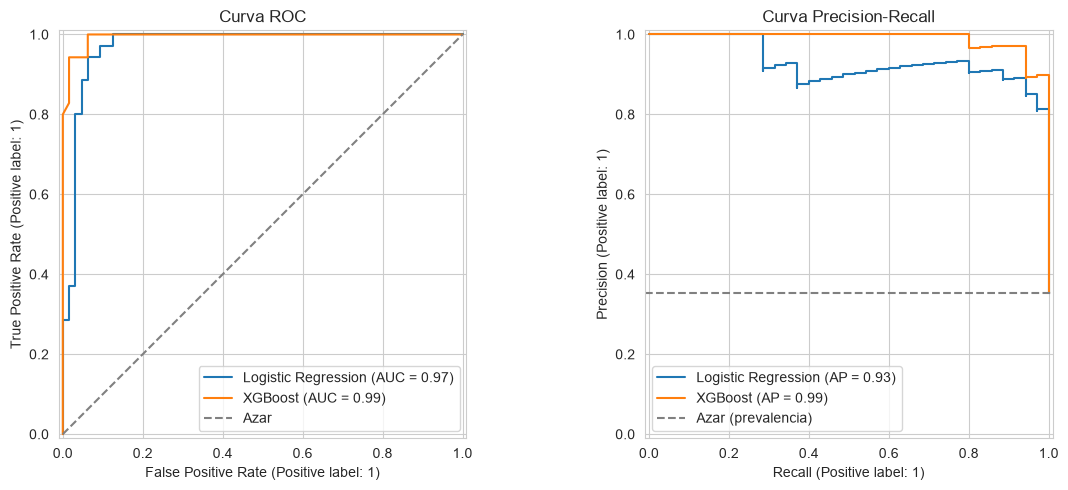

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_title('Curva ROC')
axes[0].legend()

for name, proba in [('Logistic Regression', logreg_proba), ('XGBoost', xgb_proba)]:
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Azar (prevalencia)')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Matrices de confusión

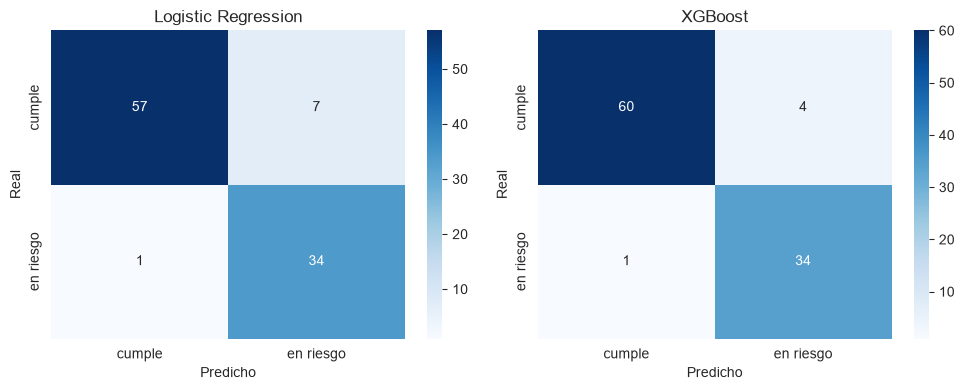

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, pred) in zip(axes, [('Logistic Regression', logreg_pred), ('XGBoost', xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['cumple', 'en riesgo'], yticklabels=['cumple', 'en riesgo'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 8. Importancia de features (XGBoost)

Chequeo de sanidad: si las features históricas (`agent_prior_pass_rate`, `agent_prior_avg_calls`) que reemplazaron a `avg_aht` no aportan nada, el modelo no tiene señal real y hay que revisar la fase de feature engineering.

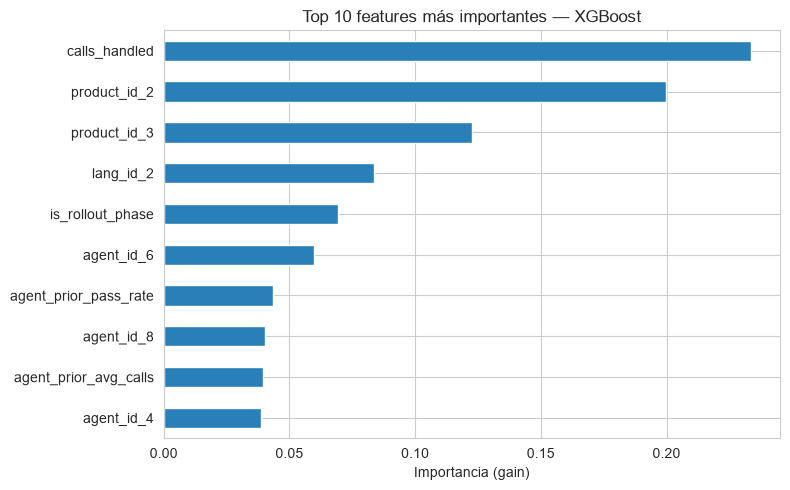

calls_handled            0.233468
product_id_2             0.199758
product_id_3             0.122684
lang_id_2                0.083790
is_rollout_phase         0.069297
agent_id_6               0.059799
agent_prior_pass_rate    0.043455
agent_id_8               0.040465
agent_prior_avg_calls    0.039639
agent_id_4               0.038771
dtype: float32

In [10]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.iloc[::-1].plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title('Top 10 features más importantes — XGBoost')
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

importances

## 9. Validación cruzada sobre train

Con solo 171 filas de train, una sola métrica de test puede ser ruidosa. Se corre `StratifiedKFold` (5 folds) sobre train como chequeo de estabilidad — no reemplaza al test holdout cronológico, es un diagnóstico adicional de varianza.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_logreg = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='roc_auc')
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'Logistic Regression — ROC-AUC CV: {cv_scores_logreg.mean():.3f} +/- {cv_scores_logreg.std():.3f}')
print(f'XGBoost             — ROC-AUC CV: {cv_scores_xgb.mean():.3f} +/- {cv_scores_xgb.std():.3f}')

Logistic Regression — ROC-AUC CV: 0.970 +/- 0.017
XGBoost             — ROC-AUC CV: 0.988 +/- 0.010


## 10. Conclusiones de la fase de Modeling

1. **Ambos modelos superan claramente al baseline** (que tiene 0% de recall en la clase de interés por construcción), confirmando que sí hay señal predictiva real sin usar `avg_aht`.
2. **Comparación baseline vs. principal:** ver la tabla de la sección 6 para los números concretos de esta corrida — se reporta ROC-AUC y PR-AUC porque accuracy sola es engañosa incluso con un desbalance moderado. XGBoost superó a Logistic Regression en ambas métricas.
3. **Features más relevantes (corrigiendo una hipótesis inicial):** se esperaba que `agent_prior_pass_rate` dominara la importancia, pero el resultado real (sección 8) muestra que `calls_handled` y `product_id` encabezan el ranking. Es decir, el riesgo de incumplimiento está más ligado al volumen del día y al producto/cola atendida que al historial del agente — una revisión útil de la intuición inicial, y coherente con que el estándar de AHT probablemente varíe por producto.
4. **Métricas altas, dataset pequeño — leer con cautela:** ROC-AUC y PR-AUC por encima de 0.97 en el holdout son inusualmente altos. Con solo 171 filas de train y 99 de test, esto es tan consistente con una señal genuinamente fuerte (algunos productos/queues son estructuralmente más difíciles de cumplir) como con sobreajuste o con que el dataset sea sintético/simplificado. La validación cruzada de la sección 9 ayuda a contextualizar esto, pero no lo resuelve del todo — antes de usar este modelo para decisiones reales de dotación, haría falta validarlo contra más meses de datos.
5. **Lo que falta:** este notebook usó el umbral de decisión por defecto (0.5). Ese umbral es arbitrario desde la perspectiva de negocio — no refleja el costo real de un falso negativo (SLA incumplido sin alerta) frente a un falso positivo (sobre-dotación innecesaria).

**Siguiente paso:** `04_evaluation.ipynb` — definir el costo de negocio de cada tipo de error, encontrar el umbral de decisión óptimo, y traducir el resultado del modelo en una recomendación de dotación de personal.